## Reid Detmer Performance Analysis
#### By: Seth Richards

Over the last few weeks, I've had the opportunity to watch three of Los Angeles Angels starter Reid Detmers' games. I've been impressed with his outings, and I wanted to take some time to dive into what has been working for him and why I believe he could become a top-tier pitcher in this league. 

The data in this report is taken from MLB Statcast using the Python package pybaseball. This data is updated through September 8th, 2026. I've included the code used to generate the charts and tables I created to help highlight Detmers' strengths. 

## Background 
Detmers was selected 10th overall in the first round of the 2020 Draft by the Angels out of the University of Louisville. Coming out of college, he was projected to be a mid-rotation starter in his 2021 Scouting Report on MLB.com [link here](https://www.mlb.com/milb/prospects/2021/angels/reid-detmers-672282).

The Angels quickly called Detmers up for his MLB Debut on August 1st, 2021, where he gave up 6 runs in 4.1 innings against the Athletics. He made 4 more starts that season, with a stint on the injury list sidelining him until September 2021. 

Detmers returned to the Angels rotation for the 2022 season, where he pitched 129 innings in 25 starts. His 3.77 ERA and 1.21 WHIP showed promise and were highlighted by a 108-pitch no-hitter against the Rays on May 10th. 2023 and 2024 were steps backward for Detmers. He wasn’t able to find consistency across his starts and keep runs off the board. May 2024, he allowed 26 earned runs in 24.2 innings, while never pitching through the 6th inning in any of his 5 starts this month. Detmers was sent down to AAA Salt Lake in June 2024 and wasn’t recalled until September that season. His struggles continued, however, with back-to-back starts giving up 7 runs. 

Los Angeles decided to take a different approach with Detmers for the 2025 season. He worked exclusively out of the bullpen, appearing in 61 games with a 3.96 ERA. 12 of the 28 earned runs he allowed came within a 3 game rough stretch from April 30th to May 7th. Outside of that week, he was one of the Angels' most reliable relievers. 

The 2026 season allowed Detmers to return to the starting rotation, and he hasn’t looked back since Opening Day. He’s started 28 games this season and thrown 162 innings to a 3.44 ERA and 182 strikeouts at the time of this writing. This past August, he threw 30 innings across 5 starts and allowed only 5 runs, one of the best months of his career. 

In this analysis, I want to explore his arsenal and what he’s doing well to have this resurgence in his career. 

## Notes from 8/28 start against the Phillies
I want to quickly start with some notes I had from watching a recent start against the Phillies at home. My goal for watching this game was to follow along with Detmers' game plan and see if I could identify any specific approaches or strategies he employed against a lineup I am familiar with. Watching this game helped guide the exploration I wanted to go down in this analysis, so here were the three biggest takeaways I had from this game: 

1. Excellent Command: Detmers seemed to be consistently hitting his spots, working efficiently through a tough Phillies offense. 
2. Weak Contact: With only 2 strikeouts, Detmers found other ways to get outs. Only 2 of the 21 Balls In Play were classified as Solid Contact according to Statcast. 
3. Curveball Usage: Watching the way Phillies hitters reacted to Detmers' curveball was quite amusing. Curveballs only made up 11 of his 86 pitches, but each was strategically used.

Now let's start taking a closer look at Detmers and what I believe he is doing well. 


## Data Preparation
The following sections contain a mix of my thought process while looking into Detmers, the code I used to gather talking points, and several charts/tables to help illustrate my points

In [367]:
import pybaseball as pyb
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
from IPython.display import Image

pd.set_option('display.max_columns', 999)
pd.set_option("display.max_seq_items", None)

PLAYER_ID = 672282
PLAYER_NAME = "Reid Detmers"
DATASET_NAME = "Detmers, Reid"

In [368]:
### PITCH COLOURS ### - Borrowing from TJStats
pitch_colours = {
    ## Fastballs ##
    'FF': {'colour': '#FF007D', 'name': '4-Seam Fastball'},
    'FA': {'colour': '#FF007D', 'name': 'Fastball'},
    'SI': {'colour': '#98165D', 'name': 'Sinker'},
    'FC': {'colour': '#BE5FA0', 'name': 'Cutter'},

    ## Offspeed ##
    'CH': {'colour': '#F79E70', 'name': 'Changeup'},
    'FS': {'colour': '#FE6100', 'name': 'Splitter'},
    'SC': {'colour': '#F08223', 'name': 'Screwball'},
    'FO': {'colour': '#FFB000', 'name': 'Forkball'},

    ## Sliders ##
    'SL': {'colour': '#67E18D', 'name': 'Slider'},
    'ST': {'colour': '#1BB999', 'name': 'Sweeper'},
    'SV': {'colour': '#376748', 'name': 'Slurve'},

    ## Curveballs ##
    'KC': {'colour': "#3F26B2", 'name': 'Knuckle Curve'},
    'CU': {'colour': '#3025CE', 'name': 'Curveball'},
    'CS': {'colour': '#274BFC', 'name': 'Slow Curve'},
    'EP': {'colour': '#648FFF', 'name': 'Eephus'},

    ## Others ##
    'KN': {'colour': '#867A08', 'name': 'Knuckleball'},
}

dict_colour = dict(zip(pitch_colours.keys(), [pitch_colours[key]['colour'] for key in pitch_colours]))

dict_pitch = dict(zip(pitch_colours.keys(), [pitch_colours[key]['name'] for key in pitch_colours]))


In [369]:
# Pulling Data from Statcast - commenting out since I only need to run once and read from the CSV

# def loadSav(startdate, enddate):
#     # format = 2020-09-28
#     sav = pyb.statcast(start_dt=startdate, end_dt=enddate)
#     print('{} Rows Imported'.format(str(len(sav))))
#     return sav

# sav = loadSav('2026-03-26', '2026-09-09')
# sav.to_csv('../data2026.csv')

In [370]:
data = pd.read_csv('../data2026.csv')

In [371]:
# Some initial processing of the raw Statcast data to help with my analysis
def df_processing(df_pyb: pd.DataFrame):
    df = df_pyb.copy()

    df = df[~df["pitch_type"].isin(['UN', 'PO'])]
    
    # Define codes for different types of swings and whiffs 
    swing_code = ['foul_bunt', 'foul', 'hit_into_play', 'swinging_strike', 'foul_tip',
                  'swinging_strike_blocked', 'missed_bunt', 'bunt_foul_tip']
    whiff_code = ['swinging_strike', 'foul_tip', 'swinging_strike_blocked']

    out_code = ['field_out', 'grounded_into_double_play', 'force_out', 'sac_bunt',
                'double_play', 'fielders_choice_out', 'sac_fly']

    hit_code = ['hit_into_play']

    df['swing'] = (df['description'].isin(swing_code))
    df['whiff'] = (df['description'].isin(whiff_code))

    df['in_zone'] = (df['zone'] < 10)
    df['out_zone'] = (df['zone'] > 10)

    df['chase'] = (df.in_zone == False) & (df.swing == 1)

    df['out'] = (df['events'].isin(out_code))

    df['error'] = (df['events'].isin(['field_error']))

    df['strikeout'] = (df['events'].isin(['strikeout']))

    df['hit'] = (df.out == False) & (df.error == False) & (df['description'].isin(hit_code))

    df['ab_number'] = (
            df.groupby(['game_pk', 'inning', 'inning_topbot'])['at_bat_number']
            .rank(method='dense')
            .astype(int)
        )

    df['count'] = (df['balls'].astype(int).astype(str) + "-" + df['strikes'].astype(int).astype(str))

    df['pfx_x_in'] = df['pfx_x'] * 12
    df['pfx_z_in'] = df['pfx_z'] * 12

    contact_map = {
        1.0: 'Weak',
        2.0: 'Topped', 
        3.0: 'Under',
        4.0: 'Flare/Burner',
        5.0: 'Solid Contact',
        6.0: 'Barrel'
    }

    df['launch_speed_angle'] = df['launch_speed_angle'].map(contact_map)

    return df

data = df_processing(data)
league_curveball_data = data[data['pitch_type'] == 'CU']
player_data = data[data['pitcher'] == PLAYER_ID]

In [372]:
AVG_PLAYER_HEIGHT_FT = 6 + 1/12  

# function for plotting pitches on a strikezone. Can be used with any set of pitches, just pass in a dataframe with what to plot
def add_pitch_strike_zone(df: pd.DataFrame, ax: plt.Axes, title: str):
    plate_width_ft = 17 / 12

    z_bot = 0.27 * AVG_PLAYER_HEIGHT_FT
    z_top = 0.535 * AVG_PLAYER_HEIGHT_FT

    rect = Rectangle((-(plate_width_ft/2), z_bot),
                     plate_width_ft,                 # width
                     z_top - z_bot,                  # height
                     fill=False,
                     linewidth=2,
                     color='black', 
                     zorder=3)
    ax.add_patch(rect)

    pitch_counts = df["pitch_type"].value_counts()
    total_pitches = len(df)

    artist_to_df = {}
    handles = []
    labels = []
    for pitch_type in pitch_counts.index:
        sub = df[df['pitch_type'] == pitch_type].reset_index(drop=True)
        artist = ax.scatter(sub['plate_x'], sub['plate_z'],
                             color=dict_colour.get(pitch_type, '#9C8975'),
                             ec='black',
                             alpha=1,
                             zorder=2,
                             linewidths=0.5,
                             )
        artist_to_df[artist] = sub
        handles.append(artist)
        labels.append(f"{pitch_type}: {(pitch_counts[pitch_type] / total_pitches) * 100:.1f}%")
        
    ax.legend(handles=handles, labels=labels, title="Pitch Type")

    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(0, 5)
    ax.set_xlabel("plate_x (ft)")
    ax.set_ylabel("plate_z (ft)")
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')

In [373]:
def plot_table(df: pd.DataFrame, title: str, figsize=None, color_col=None):
    n_rows, n_cols = df.shape
    if figsize is None:
        figsize = (max(6, n_cols * 1.8), max(3, n_rows * 0.45))

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='upper center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.6)

    color_col_idx = df.columns.get_loc(color_col) if color_col else None

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(fontweight='bold', color='white')
            cell.set_facecolor('#BA0021')
        elif col == color_col_idx:
            if color_col_idx is not None:
                pitch_code = df.iloc[row - 1, color_col_idx]
                cell.set_facecolor(dict_colour.get(pitch_code, '#f2f2f2' if row % 2 == 0 else 'white'))
        elif row % 2 == 0:
            cell.set_facecolor('#f2f2f2')

    fig.subplots_adjust(top=0.85, bottom=0.02)  # trims the leftover margin below the table
    plt.show()

## Pitch Location by Batter Handedness
First up, I'd like to get a sense of what Detmers throws. The chart below shows the locations of Detmers’ pitches against left-handed and right-handed hitters. I find it interesting to look at plots like these to get a general sense of where a pitcher likes to land his pitches. Two items immediately jump out to me from these charts. The first is his arsenal against lefties. His approach against LHH is very straightforward: fastballs in and around the top parts of the zone, then sliders low and away from the batter. 87.1% of the pitches he threw fall into this bucket. The second is his use of the curveball against RHH. There’s a ton of blue in the middle of the strike zone, which goes against what I would typically expect from a pitcher. I think of curveballs as the pitch you get players to chase, but Detmers seems to be challenging hitters with it. How successful is this approach?

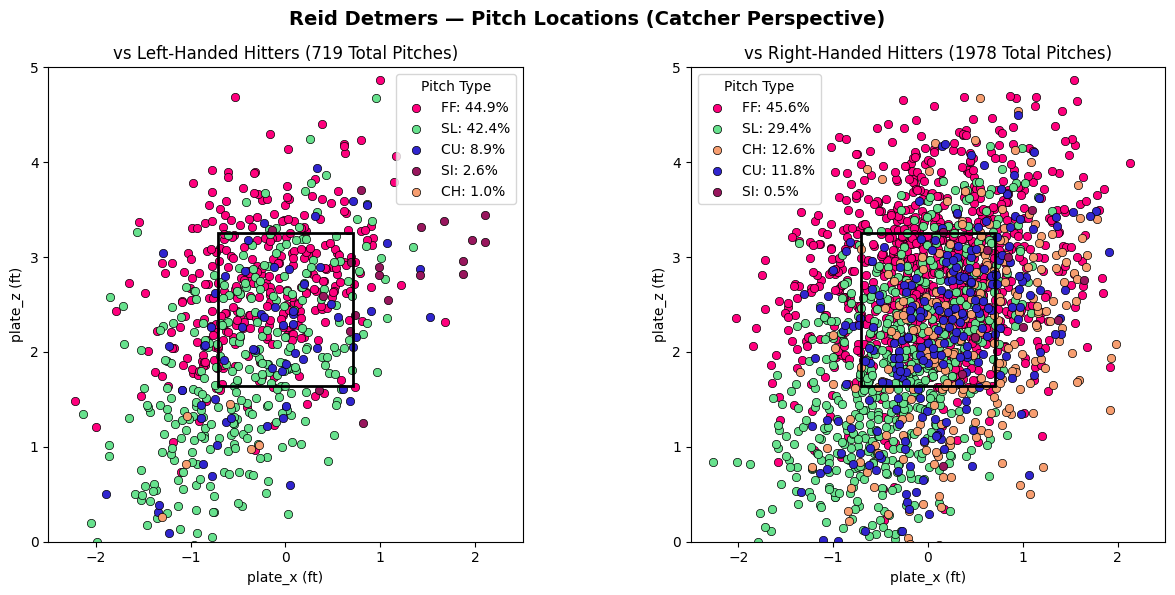

In [374]:
df_left  = player_data[player_data['stand'] == 'L']
df_right = player_data[player_data['stand'] == 'R']

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"{PLAYER_NAME} — Pitch Locations (Catcher Perspective)", fontsize=14, fontweight='bold')
add_pitch_strike_zone(df_left,  ax_l, title=f"vs Left-Handed Hitters ({len(df_left)} Total Pitches)")
add_pitch_strike_zone(df_right, ax_r, title=f"vs Right-Handed Hitters ({len(df_right)} Total Pitches)")
plt.tight_layout()
plt.show()

## The "Not So Secret" Secret Weapon

As it turns out, Detmers has had some great success with his curveball. He's thrown 285 total curveballs this season, which is not nearly as many as his 4-seam or slider, but hitters are having trouble with it. Let’s take a look at the outcomes of Detmers throwing his curveball.


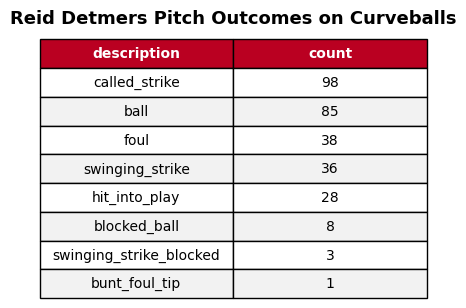

In [375]:
player_curveball_data = player_data[player_data['pitch_type'] == 'CU']
curveball_outcomes = (
    player_curveball_data['description']
    .value_counts()
    .reset_index()
)
curveball_outcomes.columns = ['description', 'count']
plot_table(curveball_outcomes, "Reid Detmers Pitch Outcomes on Curveballs", figsize=(5,3))

In [376]:
ct = pd.crosstab(league_curveball_data['player_name'], league_curveball_data['description'])

league = pd.DataFrame({
    'called_strike': ct['called_strike'],
    'total_pitches': ct.sum(axis=1)
})
league['called_strike_rate'] = round(league['called_strike'] / league['total_pitches'] * 100, 2)
league = league[league['total_pitches'] >= 100]

player_rate = league.loc[DATASET_NAME, 'called_strike_rate']
league_avg = league['called_strike_rate'].mean()
percentile = (league['called_strike_rate'] < player_rate).mean() * 100

print(f"{PLAYER_NAME}: {player_rate}% called strike rate")
print(f"League average: {league_avg:.2f}%")
print(f"Percentile: {percentile:.0f}th")

Reid Detmers: 33.0% called strike rate
League average: 18.83%
Percentile: 99th


98 called strikes? That doesn’t seem quite right. But sure enough, the numbers don’t lie. Detmers' curveball is the most often called a strike in the league, by a good margin. He's in the 99th percentile for curveballs called for a strike this year at 32.98%, when the league average is jst 18.72%. Below are the pitchers who have the highest number of called strikes on their curveball this season. Everyone above Detmers on this list has at least 500 total curveballs thrown this season. This table is ranked on the highest number of called strikes on a curveball.

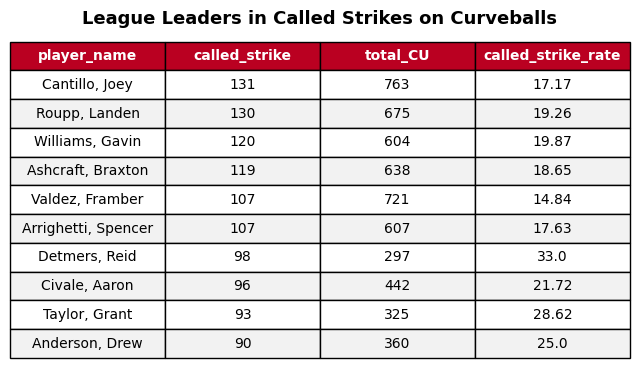

In [377]:
ct = pd.crosstab(league_curveball_data['player_name'], league_curveball_data['description'])

summary = pd.DataFrame({
    'called_strike': ct['called_strike'],
    'total_CU': ct.sum(axis=1)
}).sort_values('called_strike', ascending=False).head(10)
summary['called_strike_rate'] = round(summary['called_strike'] / summary['total_CU'] * 100, 2)
plot_table(summary.reset_index(), "League Leaders in Called Strikes on Curveballs", figsize=(8,4))

What really sets Detmers apart is the command of his curveball. He’s thrown it for a called strike 13 more times than it has been called a ball. Turns out that’s not so common this season either. He has the highest difference between called strikes and balls on curveballs this season. The table below is ranked by the highest difference.

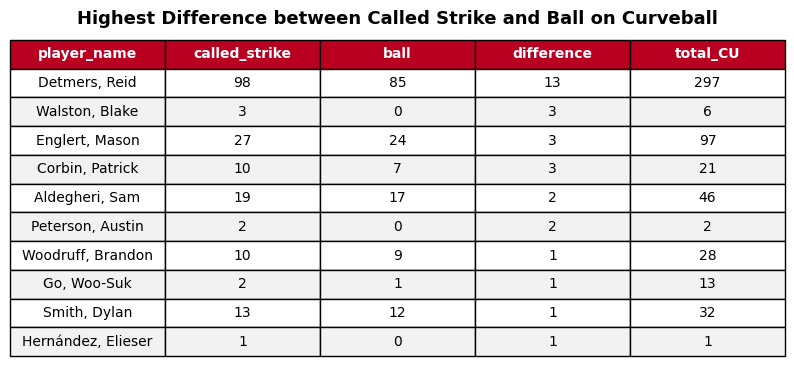

In [378]:
ct = pd.crosstab(league_curveball_data['player_name'], league_curveball_data['description'])

summary = pd.DataFrame({
    'called_strike': ct['called_strike'],
    'ball': ct['ball'],
    'difference': ct['called_strike'] - ct['ball'],
    'total_CU': ct.sum(axis=1)
}).sort_values(['difference'], ascending=False).head(10)

plot_table(summary.reset_index(), "Highest Difference between Called Strike and Ball on Curveball", figsize=(10, 3))

I’d call this pitch the "Not So Secret" Secret Weapon because it truly is unique. If you watch him throw it and pay attention to the hitter's reaction, you can start to understand why his rate is so high. Out of the hand, it looks like that ball has no business landing near the strike zone. One of my favorite pitches from his start against the Phillies was this pitch to Harper, where he immediately challenges the pitch after the umpire gives his strike call. [Harper ABS Challenge (Source: MLB Film Room)](https://www.mlb.com/video/reid-detmers-called-strike-to-bryce-harper?q=gamePk%20=%20823985%20AND%20Inning%20=%20[6]%20Order%20By%20Timestamp%20ASC&p=0&pt=Pitch%20by%20Pitch%20-%206th%20Inning) Now it makes sense why this pitch was graded high coming out of college. He doesn’t throw it often, but when he does, he throws it with the intention of catching the hitter off guard and giving himself an advantage in the count.

The curveball doesn’t just pass the eye test. It’s got the movement stats to back it up. The next table shows Detmers’ movement stats on all his pitches and the comparison to a league-average left-handed pitcher for each pitch type. The pfx_x taken from Statcast represents the horizontal movement (in inches) from the catcher's perspective, and similarly, pfx_z represents the vertical movement. Also note that negative values represent the glove-side run, and positive values represent the arm-side run for horizontal movement. 

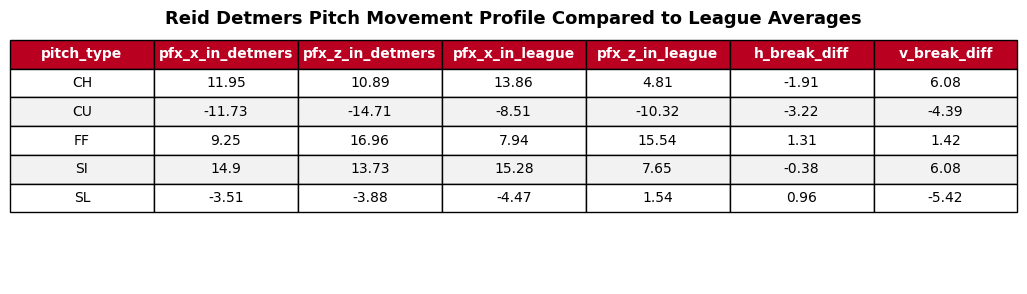

In [379]:
pitcher_movement = (
    data[data['pitcher'] == PLAYER_ID]
    .groupby('pitch_type')[['pfx_x_in', 'pfx_z_in']]
    .mean().round(2)
)

league_movement = (
    data.groupby(['pitch_type', 'p_throws'])[['pfx_x_in', 'pfx_z_in']]
    .mean().round(2)
)
comparison = pitcher_movement.merge(
    league_movement.xs('L', level='p_throws'),
    on='pitch_type',
    suffixes=('_detmers', '_league')
)

comparison['h_break_diff'] = round(comparison['pfx_x_in_detmers'] - comparison['pfx_x_in_league'], 2)
comparison['v_break_diff'] = round(comparison['pfx_z_in_detmers'] - comparison['pfx_z_in_league'], 2)
plot_table(comparison.reset_index(), "Reid Detmers Pitch Movement Profile Compared to League Averages", figsize=(13, 3))

The last part of Detmers curveball to mention is how hitters are reacting to it. Here we can see the count of each AB ending event on the curveball, which shows how hard it is to put this ball in play for a hit (8 of 51 events). 

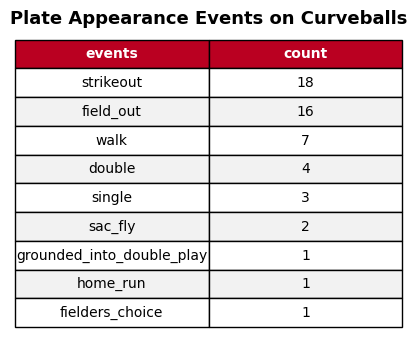

In [380]:
player_curveball_data['events'].value_counts()
player_curveball_events = (
    player_curveball_data['events']
    .value_counts()
    .reset_index()
)
plot_table(player_curveball_events, "Plate Appearance Events on Curveballs", figsize=(5, 3))

The launch_speed_angle is one of Statcast’s methods for gauging exit velocity and launch angle, on the following scale, further illustrating how much trouble players have getting good contact off this pitch. Just 3 of the 26 curveballs put in play were barreled o rhit with solid contact. 

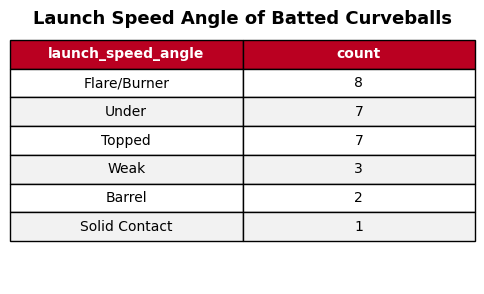

In [381]:
player_curveball_data['launch_speed_angle'].value_counts()
player_curveball_lsa = (
    player_curveball_data['launch_speed_angle']
    .value_counts()
    .reset_index()
)
plot_table(player_curveball_lsa, "Launch Speed Angle of Batted Curveballs", figsize=(6,3))

## Don't forget about the Slider
I’d also like to give his slider some flowers, as it was a great pitch to watch him execute during games. From the movement table above, we can see that his slider has 5.41 more inches of downward break than a league-average left-handed slider does, which is part of what makes it so effective. In fact, it’s one of the best strikeout pitches in the league. Below is a table of the individual pitches that have generated the most strikeouts so far this season, and Detmers sits at 8th with his slider, behind Chris Sale and Chase Burns sliders. Not bad company to be in. To illustrate the slider in action, here’s how the at-bat ended to Bryce Harper. [Video Link Here to MLB Film Room](https://www.mlb.com/video/bryce-harper-strikes-out-swinging-ti5hht?q=gamePk%20=%20823985%20AND%20Inning%20=%20[6]%20Order%20By%20Timestamp%20ASC&p=0&pt=Pitch%20by%20Pitch%20-%206th%20Inning )


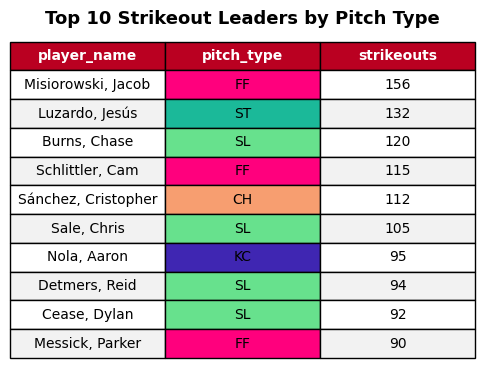

In [382]:
strikeout_events = data[data['events'].isin(['strikeout', 'strikeout_double_play'])]

strikeouts_by_pitch = (
    strikeout_events.groupby(['player_name', 'pitch_type'])
    .size()
    .reset_index(name='strikeouts')
)

top10 = strikeouts_by_pitch.sort_values('strikeouts', ascending=False).head(10)
plot_table(top10, "Top 10 Strikeout Leaders by Pitch Type", figsize=(6, 4), color_col="pitch_type")

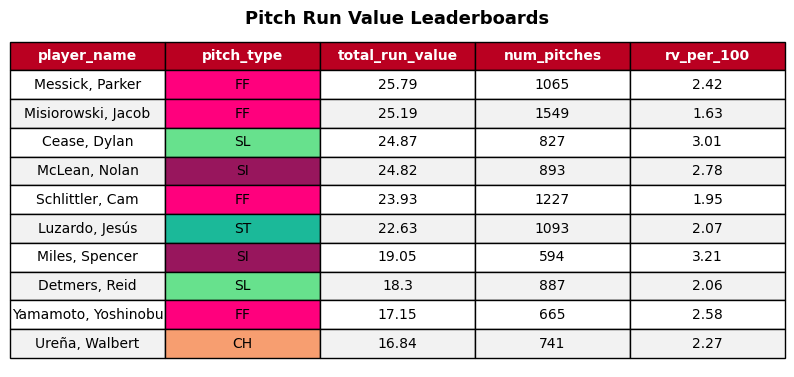

In [383]:
run_value = (
    data.groupby(['player_name', 'pitch_type'])['delta_run_exp']
    .agg(total_run_value='sum', num_pitches='count')
    .round(2)
)
run_value['total_run_value'] = run_value['total_run_value'] * -1
run_value['rv_per_100'] = (run_value['total_run_value'] / run_value['num_pitches'] * 100).round(2)
run_value = run_value.reset_index() 

plot_table(run_value.sort_values('total_run_value', ascending=False).head(10), "Pitch Run Value Leaderboards", figsize=(10, 4), color_col="pitch_type")

## Looking at Pitch Usage in Different Counts

The last topic I want to investigate is when Detmers throws his pitches and in which counts. The following 3 heatmaps show the initial count at which a pitch was thrown and the outcome of that pitch. For example, in a 0-0 count, Detmers has thrown his curveball 35 times, and the result has been a ball. 

In [384]:
def plot_pitch_count_usage(df: pd.DataFrame, title: str):
    situation = (
        pd.crosstab(df['description'], df['count'])
    )

    fig, ax1 = plt.subplots(figsize=(10, 6))

    sns.heatmap(situation, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=True)
    ax1.set_title(f"Detmers {title} Pitch Results by Count",  fontweight='bold')

    plt.tight_layout()
    plt.show()

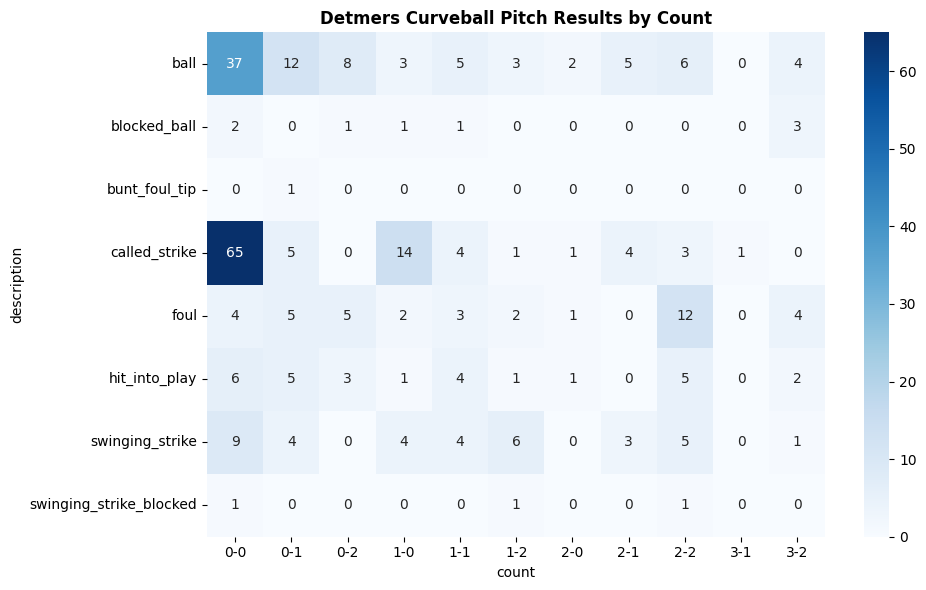

In [385]:
player_curveball_data = player_data[player_data['pitch_type'] == 'CU']
plot_pitch_count_usage(player_curveball_data, "Curveball")

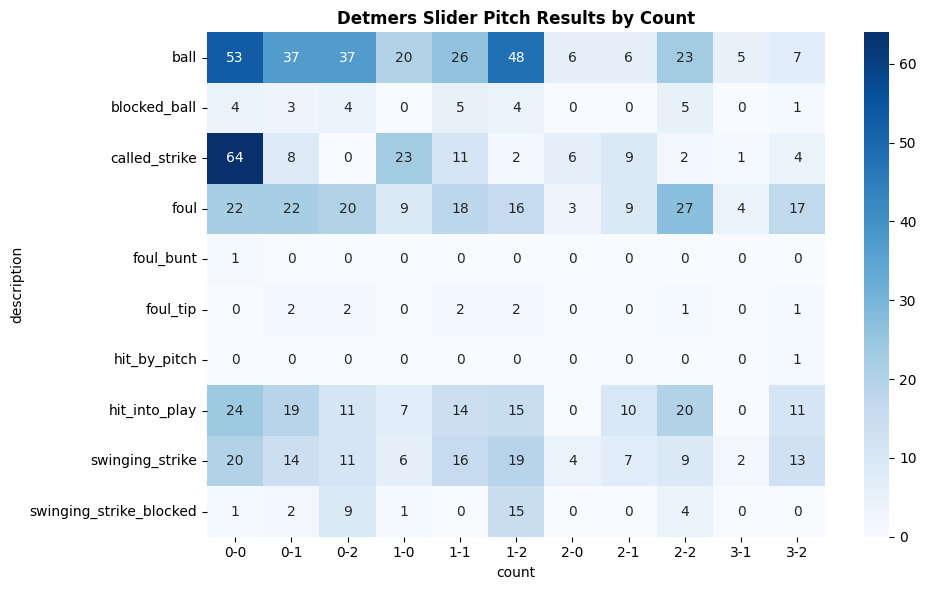

In [386]:
pitcher_slider_data = player_data[player_data['pitch_type'] == 'SL']
plot_pitch_count_usage(pitcher_slider_data, "Slider")

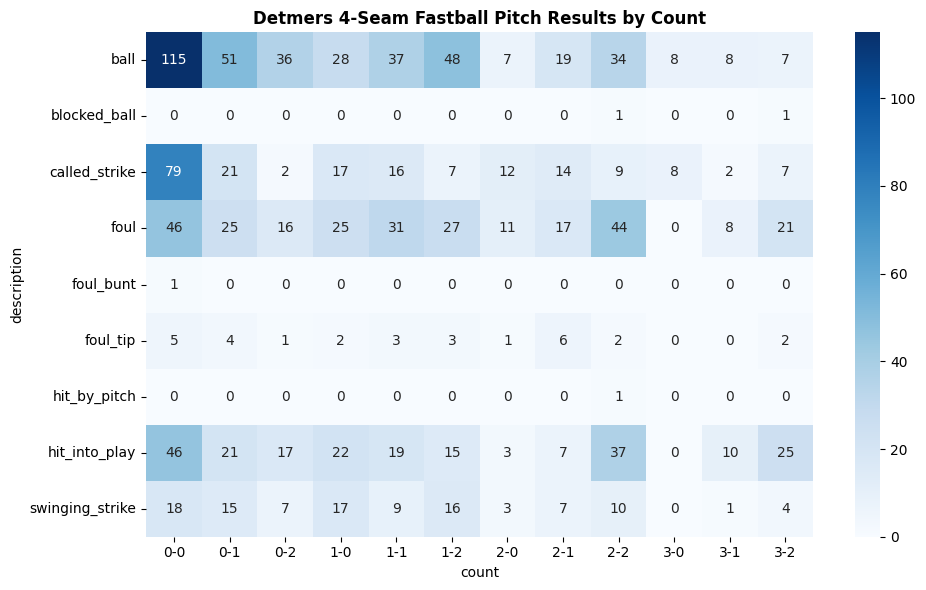

In [387]:
pitcher_four_seam_data = player_data[player_data['pitch_type'] == 'FF']
plot_pitch_count_usage(pitcher_four_seam_data, "4-Seam Fastball")

What still jumps out is the ability to throw his curveball for strikes. Keep in mind that a strike in these tables is split between several different outcomes, but the usage is still fascinating to me. He uses his curveball early in counts (0-0, 1-0) to try to get ahead or even with the batter. He can then leverage that favorable count to put batters away with his fastball or slider. I also can’t help but see how empty the 2-0 and 3-0 count columns are for each pitch. Detmers’ command and ability to limit long at-bats were noticeable during his outing against the Phillies. Rarely does he get into hitter-friendly counts due to how he attacks the zone. 


## Conclusion 

If you’ve made it this far, thanks! This is the first time I’ve done something like this, and I really appreciate you taking the time to read through my thoughts. I would love to hear any feedback you have on how I can improve or what additional data points I should look out for. If you just skipped to the end, that’s ok too. Here’s a summary of what I think about Reid Detmers. 

- His pitch mix is simple, yet effective. He has an unconventional use of his curveball to catch hitters off guard, instead of trying to get chases. The slider is one of the best strikeout pitches in baseball and seems to complement his curveball, giving him 2 elite breaking ball options in his arsenal. Both pitches have a sub .200 batting average, according to Baseball Savant. 
- He has excellent command of his arsenal, which allows him to work through innings efficiently. He’s not afraid to throw his pitches for strikes and challenge hitters.
- I am curious how he will develop further and what the next step of his evolution will be. Increasing his sinker usage to play off his fastball might bolster what his fastball has to offer. 

Detmers has started to show, with his aggressive pitching style and excellent command of his arsenal, that he can be a top arm in this league. His emergence this season has been a bright spot for the Angels, and I hope he continues to prove that their investment in him was worthwhile. 
